### The HR diagram   (...and the importance of data scaling in machine learning)

We will work with a star catalogue of 240 stars described by the following information:

- Temperature (in Kelvin)
- Luminosity (L/Lo)
- Radius (R/Ro)
- Absolute magnitude (Mv)

We also have the following data for each star:

- Color (Red/Orange/Yellow/White/Blue)
- Spectral class ('A', 'B', 'F', 'G', 'K', 'M', 'O')
- Star type (Brown dwarf/Red dwarf/White dwarf/Main sequence/Supergiant/Hypergiant)


In [25]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x2057352d350>)

In [26]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


There are 6 star types that are encoded in the *'Star type'* column. These labels are currently encoded as strings which is practical for reading but not for computing. Using scikit-learn, we will convert this column into integers by assigning a unique int value to each star type.

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

[0 1 2 3 4 5]


We've seen this already last time. It is often grood practice to start with a statistical analysis of the dataset to answer the following questions:
* are there any missing values?
* are there NaNs in the data?

Temperature (K)           length = 240    NaNs = 0     
Luminosity(L/Lo)          length = 240    NaNs = 0     
Radius(R/Ro)              length = 240    NaNs = 0     
Absolute magnitude(Mv)    length = 240    NaNs = 0     
Star type                 length = 240    NaNs = 0     
Star color                length = 240    NaNs = 0     
Spectral Class            length = 240    NaNs = 0     


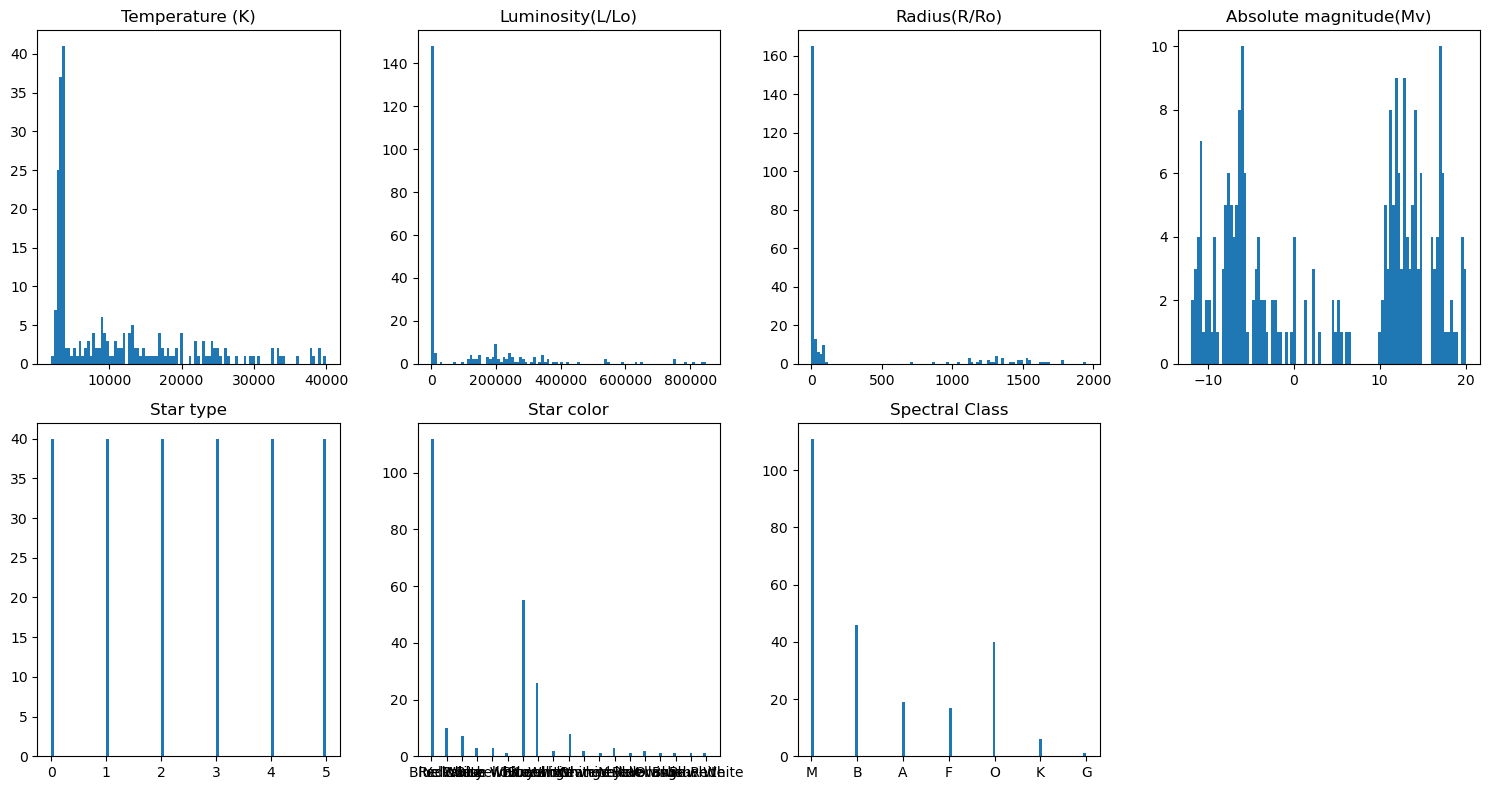

In [28]:
import matplotlib.pyplot as plt
labels = df_stars.columns.to_numpy()
fig, ax = plt.subplots(2,4, figsize=(15, 8))
ax = ax.flatten()

for idx, col in enumerate(labels[:7]):
    ax[idx].hist(df_stars[col].dropna(), bins=100)
    ax[idx].set_title(col)
    print(f"{col:<25} length = {len(df_stars[col]):<6} NaNs = {df_stars[col].isna().sum():<6}")
fig.delaxes(ax[7])
fig.tight_layout()

There are no missing values nor any NaNs in the data!

We can reproduce the HR diagram by plotting the scatter plot of our stars using the same variables in log-log-scale.

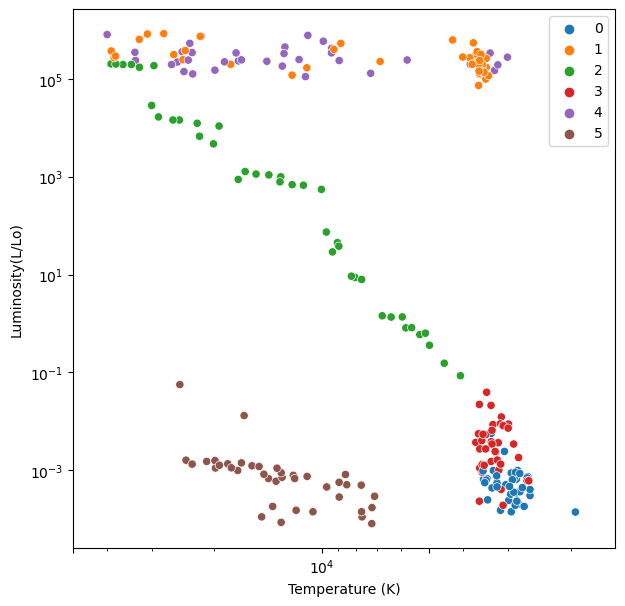

In [31]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

We find the same organization of stars in this 2D plane. Main Sequence stars and White Dwarves are fairly easy to isolate from the rest: a statistical model should be able to easily classify them. Based only on Luminosity and Temperature, Dwarf stars and Giant stars have higher intra-group variability: Supergiant and Hypergiant cover the same space (same for Brown and Red Dwarves). Additionnal variables might be needed to correctly identify the types of those stars.

- Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
- Project the dataset into the principal components, and do a scatter plot of the first two. 
- This will look terrible. Think about the units!
- Explore what happens if you rescale the data first.

**This is actually a very important lesson in machine learning**: Massaging your data before giving them to an algorithm can make things much much better.

- You can try an linear, affine transformation such that each dimension goes between -1 and 1.
- Or (which is [the usual machine-learning approach](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) standardize your data such that each dimension has mean=0 and variance=1. 
- Redo your PCA. Should be much much better.
- How much variance is explained by those two components?

Let's start by allpying PCA to the dataset:

In [32]:
import numpy as np
from sklearn.decomposition import PCA

Explained variance ratio: ['99.76063126866043%', '0.2387899198052245%', '0.0005786772601574159%', '1.342741890605354e-07%']


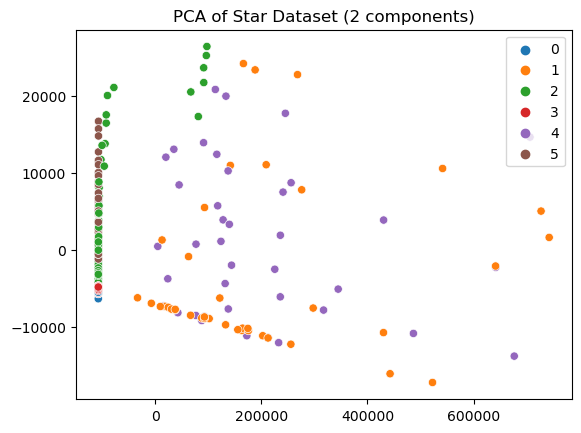

In [34]:
num_data = df_stars.drop(columns=['Star type', 'Star color', 'Spectral Class']).to_numpy() # Discard all the colums that are not numerical
pca = PCA(n_components=4)
data_pca = pca.fit_transform(num_data)

print("Explained variance ratio:", [f"{v:}%" for v in pca.explained_variance_ratio_*100])

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=labels, palette='tab10')
plt.title('PCA of Star Dataset (2 components)')
plt.show()

This looks horrible, but if we rescale the data we get:

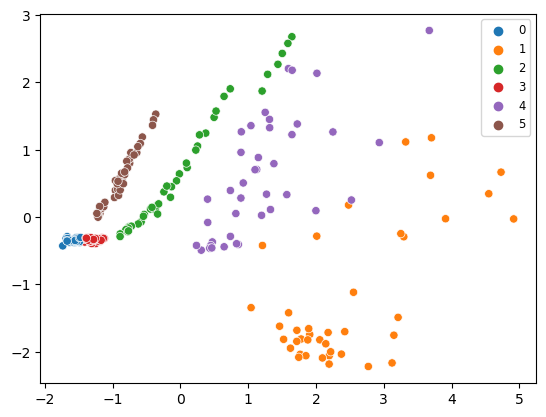

In [36]:
mu = np.mean(num_data, axis = 0)
sigma = np.std(num_data, axis = 0)
data_rescaled = (num_data-mu)/sigma

pca_rescaled = pca.fit_transform(data_rescaled)

sns.scatterplot(x=pca_rescaled[:, 0], y=pca_rescaled[:, 1], hue=labels, palette='tab10')
plt.legend(fontsize='small')

This rescaling was done by hand, but we should get the same result if we use the standardizing Sklearn method:

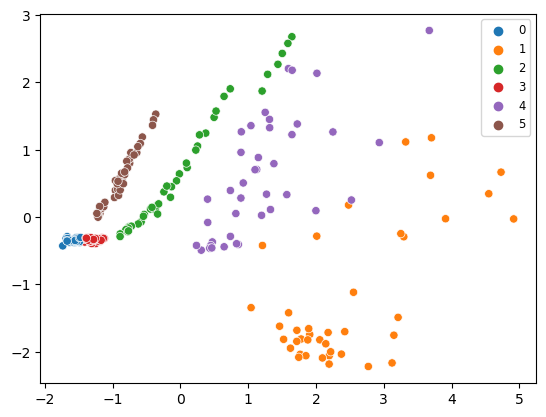

In [37]:
from sklearn.preprocessing import StandardScaler

stnd_scaler = StandardScaler()
data_stndscaled = stnd_scaler.fit_transform(num_data)

pca_stndscaled = pca.fit_transform(data_stndscaled)

sns.scatterplot(x=pca_stndscaled[:, 0], y=pca_stndscaled[:, 1], hue=labels, palette='tab10')
plt.legend(fontsize='small')

They indeed look the same!

Let's see how much variance is explained by each component by looking at the scree plot:

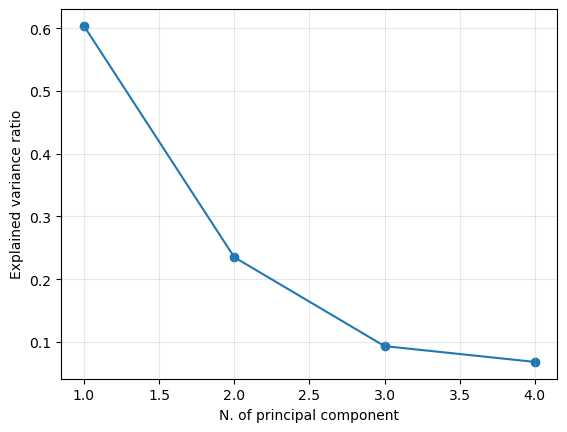

In [38]:
n_components = pca.n_components_
evals = pca.explained_variance_ratio_

x_grid = np.arange(n_components)+1
plt.plot(x_grid, evals)
plt.scatter(x_grid, evals)
plt.xlabel('N. of principal component')
plt.ylabel('Explained variance ratio')
plt.grid(alpha=0.3)

In [ ]:
print('Explained variance ratio:', [f'{v:}' for v in evals*100])
print(f'The first two components explain {np.sum(evals[:2])*100:.3f} % of the variance!')

Explained variance ratio: ['60.357390915734', '23.500784164700804', '9.329645164756558', '6.8121797548086365']
The first two components explain 83.858 % of the variance!
